In [26]:
import RandomSquareGenerator
import joblib # for saving large variables (dont need to re run)
import LatinSquares # ensure copy of notebook is upto date -> jupyter nbconvert --to python LatinSquares.ipynb
from collections import defaultdict, Counter # default python library
import scipy.stats as stat
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def generate_random_squares_counts(n:int, num_squares:int = 100000, num_moves:int = 100) -> dict:
    '''
    Generates num_squares random nxn latin squares and returns a dictionary of how many times 
    each unique square appeared in the sample. num_moves specifies how many moves the shuffler
    makes to randomize each new square
    '''
    square_counts = defaultdict(int)
    
    for _ in range(num_squares):
        latin = RandomSquareGenerator.rlatin(n,Minmoves=num_moves)
        latin.shuffle()

        # Convert to tuple-of-tuples for hashing
        square_key = tuple(tuple(int(val) for val in row) for row in latin.store)
        square_counts[square_key] += 1
    
    return square_counts

In [113]:
def generate_random_squares(n:int, size:int):
    sample = []
    for _ in range(size):
        square = RandomSquareGenerator.rlatin(n,Minmoves=25)
        square.shuffle()
        hashed = LatinSquares.hash_square(square.store)
        sample.append(hashed)
    return sample

### Part 1. Proving Randomness and Finding Required Shuffle Depth

In [ ]:
def generate_move_effect_samples(shuffle_values:list,n:int =5,num_runs:int =5,sample_size:int=100000) -> dict:
    '''
    Generates and compiles #{num_runs} samples of distinct latin square counts using generate_random_square and returns 
    the total amount of unique squares in each sample. Used to evaluate randomness/distribution  of generator
    '''
    results = {}

    for moves in shuffle_values:
        print(moves)
        counts = []
        for _ in range(num_runs):
            squares = generate_random_squares_counts(n=n, num_squares=sample_size, num_moves=moves)  # your generator
            unique = len(set(tuple(map(tuple, s)) for s in squares))
            counts.append(unique)
            print(_)
        results[moves] = counts
    return results

In [ ]:
# Generate 10 5x5 samples of 100 000 squares for 10 shuffles, 15 shuffles... 200 shuffles
move_effect_samples = generate_move_effect_samples([10,15,20,25,30,35,40,45,50,100,200],num_runs=10)

In [ ]:
move_effect_sample_six = generate_move_effect_samples([10,15,20,25,30,35,40,45,50,100,200],n=6,num_runs=10)

In [ ]:
# Save Samples
#joblib.dump(move_effect_samples, "move_effect_samples.joblib")
#joblib.dump(move_effect_sample_six, "move_effect_samples_six.joblib")

# Load Samples
# move_effect_samples = joblib.load("move_effect_samples.joblib")
#move_effect_sample_six = joblib.load("move_effect_samples_six.joblib")

['move_effect_samples.joblib']

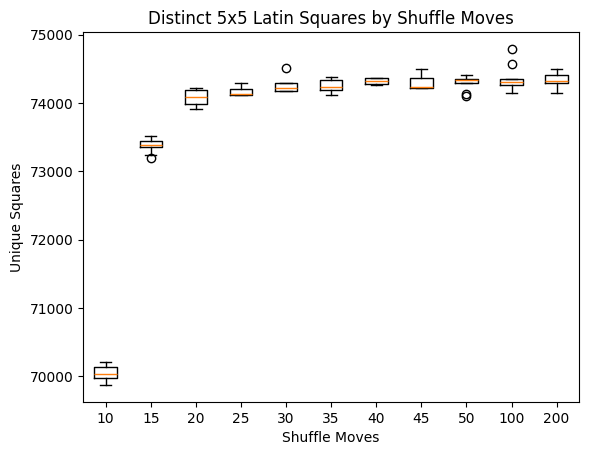

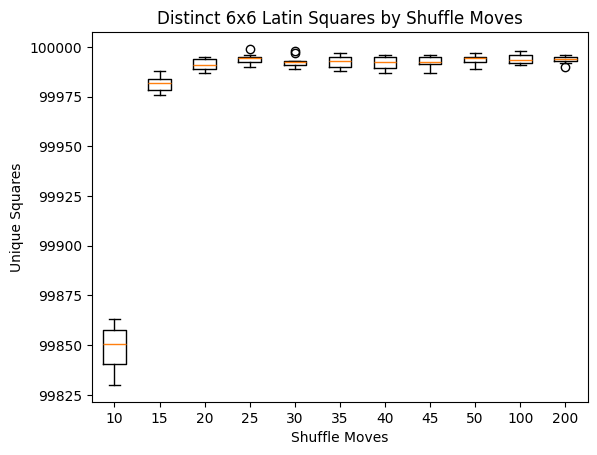

In [136]:
shuffle_values = [10,15,20,25,30,35,40,45,50,100,200]
plt.boxplot([move_effect_samples[m] for m in [10,15,20,25,30,35,40,45,50,100,200]], labels=['10','15','20','25','30','35','40','45','50','100','200'])
plt.title("Distinct 5x5 Latin Squares by Shuffle Moves")
plt.xlabel("Shuffle Moves")
plt.ylabel("Unique Squares")
plt.show()

plt.boxplot([move_effect_sample_six[m] for m in [10,15,20,25,30,35,40,45,50,100,200]], labels=['10','15','20','25','30','35','40','45','50','100','200'])
plt.title("Distinct 6x6 Latin Squares by Shuffle Moves")
plt.xlabel("Shuffle Moves")
plt.ylabel("Unique Squares")
plt.show()


First test if each sample is normally distributed.

$H_o$: The sample comes from a normally distributed population  
$H_a$: The sample does not come from a normal distribution

In [157]:
def check_sample_normality(results):
    for moves in [10,15,20,25,30,35,40,45,50,100,200]:
        data = results[moves]
        statistic, p = stat.shapiro(data)
        print(f"Shuffle {moves:>3}: W={statistic:.4f}, p={p:.5f}")

check_sample_normality(move_effect_samples)

Shuffle  10: W=0.9510, p=0.68031
Shuffle  15: W=0.9360, p=0.50982
Shuffle  20: W=0.9208, p=0.36380
Shuffle  25: W=0.8431, p=0.04803
Shuffle  30: W=0.8511, p=0.05988
Shuffle  35: W=0.9468, p=0.63088
Shuffle  40: W=0.8966, p=0.20097
Shuffle  45: W=0.9551, p=0.72924
Shuffle  50: W=0.8247, p=0.02889
Shuffle 100: W=0.8312, p=0.03461
Shuffle 200: W=0.9506, p=0.67582


Not all groups are normally distributed, thus use the kruskal wallis test

KRUSKAL-WALLIS: * groups are not normal

$H_o$: All group (distinct squares) distributions are equal (same median)  
$H_a$: At least one group (distinct squares) is different 

In [148]:
# Based on the qq plots, im exlcuding samples > 35
h_stat, p_val = stat.kruskal(move_effect_samples[15],move_effect_samples[20],move_effect_samples[25],move_effect_samples[30],move_effect_samples[35])

print(f"Kruskal–Wallis: H = {h_stat:.4f}, p = {p_val:.5f}")

Kruskal–Wallis: H = 31.0025, p = 0.00000


p < 0.05 thus reject the null hypothesis, atleast one group differs

In [154]:
h_stat, p_val = stat.kruskal(move_effect_samples[15], move_effect_samples[20])
print(f"15 vs 20 Shuffle groups Kruskal–Wallis: H = {h_stat:.4f}, p = {p_val:.5f}")
h_stat, p_val = stat.kruskal(move_effect_samples[20], move_effect_samples[25])
print(f"20 vs 25 Shuffle groups Kruskal–Wallis: H = {h_stat:.4f}, p = {p_val:.5f}")
h_stat, p_val = stat.kruskal(move_effect_samples[25], move_effect_samples[30])
print(f"25 vs 30 Shuffle groups Kruskal–Wallis: H = {h_stat:.4f}, p = {p_val:.5f}")

15 vs 20 Shuffle groups Kruskal–Wallis: H = 14.2857, p = 0.00016
20 vs 25 Shuffle groups Kruskal–Wallis: H = 4.4800, p = 0.03429
25 vs 30 Shuffle groups Kruskal–Wallis: H = 1.6514, p = 0.19876


There is no significant difference in the distribution of Latin squares between 25 and 30 shuffles, suggesting that 25 shuffles may be sufficient to reach the generator’s asymptotic randomness. Now test with the 6x6 samples.

In [156]:
h_stat, p_val = stat.kruskal(move_effect_sample_six[15], move_effect_sample_six[20])
print(f"15 vs 20 Shuffle groups Kruskal–Wallis: H = {h_stat:.4f}, p = {p_val:.5f}")
h_stat, p_val = stat.kruskal(move_effect_sample_six[20], move_effect_sample_six[25])
print(f"20 vs 25 Shuffle groups Kruskal–Wallis: H = {h_stat:.4f}, p = {p_val:.5f}")
h_stat, p_val = stat.kruskal(move_effect_sample_six[25], move_effect_sample_six[30])
print(f"25 vs 30 Shuffle groups Kruskal–Wallis: H = {h_stat:.4f}, p = {p_val:.5f}")

15 vs 20 Shuffle groups Kruskal–Wallis: H = 13.2254, p = 0.00028
20 vs 25 Shuffle groups Kruskal–Wallis: H = 5.0604, p = 0.02448
25 vs 30 Shuffle groups Kruskal–Wallis: H = 1.6703, p = 0.19622


Same conclusion with 6x6 squares. 

### Part 2. Testing for Unifrom Distributioon

CHI-SQUARE GOODNESS OF FIT 

$H_o$: The data follows a uniform distribution  
$H_a$: The data does not follow a uniform 

5x5 case:

In [ ]:
sample_size_5x5 = 5 * 161280

all_possible_squares = LatinSquares.generate_all_squares(5)
all_possible_squares_hashed = [LatinSquares.hash_square(square) for square in all_possible_squares]

In [114]:
hashed_squares_5x5 = generate_random_squares(5,size=sample_size_5x5)

In [ ]:
# Save 5x5 Sample
#joblib.dump(hashed_squares_5x5, "./variables/hashed_sqaures_5x5_chisquare.joblib")

# Load Samples
#hashed_squares_5x5 = joblib.load("variables/hashed_squares_5x5_chisquare.joblib")

NameError: name 'joblib' is not defined

In [104]:
counts = Counter(hashed_squares_5x5)

In [107]:
observed = list(counts.values())
expected = [sum(observed)/len(counts)] * len(counts)

In [108]:
chi_stat, p_val = stat.chisquare(f_obs=observed, f_exp=expected)
observed_array = np.array(observed)
num_nonzero = np.sum(observed_array > 0)

print(f"Total unique squares observed: {num_nonzero}")
print(f"Chi-square statistic: {chi_stat:.4f}")
print(f"p-value: {p_val:.5f}")

Total unique squares observed: 160107
Chi-square statistic: 163834.1247
p-value: 0.00000


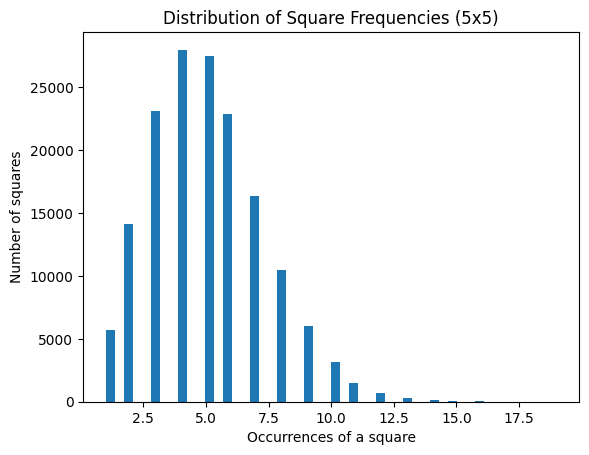

In [109]:
plt.hist(observed, bins=50)
plt.xlabel("Occurrences of a square")
plt.ylabel("Number of squares")
plt.title("Distribution of Square Frequencies (5x5)")
plt.show()